In [25]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [39]:
# 1. Configurar rutas
BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / 'data'
ruta_datos = DATA_DIR / 'Dataset_Smart_Farming_base.csv'

In [40]:
# 2. Cargar datos EDA
df = pd.read_csv(ruta_datos)

In [41]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               2500 non-null   str    
 1   region                2500 non-null   str    
 2   crop_type             2500 non-null   str    
 3   soil_moisture_%       2500 non-null   float64
 4   soil_pH               2500 non-null   float64
 5   temperature_C         2500 non-null   float64
 6   rainfall_mm           2500 non-null   float64
 7   humidity_%            2500 non-null   float64
 8   sunlight_hours        2500 non-null   float64
 9   irrigation_type       1750 non-null   str    
 10  fertilizer_type       2500 non-null   str    
 11  pesticide_usage_ml    2500 non-null   float64
 12  sowing_date           2500 non-null   str    
 13  harvest_date          2500 non-null   str    
 14  total_days            2500 non-null   int64  
 15  yield_kg_per_hectare  2500 non-n

In [42]:
print(df.head())

    farm_id       region crop_type  soil_moisture_%  soil_pH  temperature_C  \
0  FARM0001  North India     Wheat            35.95     5.99      17.456436   
1  FARM0002    South USA   Soybean            19.74     7.24      30.275671   
2  FARM0003    South USA     Wheat            29.32     7.16      27.453712   
3  FARM0004  Central USA     Maize            17.33     6.03      34.033155   
4  FARM0005  Central USA    Cotton            19.37     5.92      33.685737   

   rainfall_mm  humidity_%  sunlight_hours irrigation_type  ...  \
0        75.62   76.406275            7.27             NaN  ...   
1        89.91   60.899686            5.67       Sprinkler  ...   
2       265.43   68.954600            8.23            Drip  ...   
3       212.01   69.238224            5.03       Sprinkler  ...   
4       269.09   54.595901            7.93             NaN  ...   

  yield_kg_per_hectare      sensor_id   timestamp   latitude  longitude  \
0              4408.07  SNS-2026-0001  2024-03-

In [43]:
print(df.isnull().sum())

farm_id                   0
region                    0
crop_type                 0
soil_moisture_%           0
soil_pH                   0
temperature_C             0
rainfall_mm               0
humidity_%                0
sunlight_hours            0
irrigation_type         750
fertilizer_type           0
pesticide_usage_ml        0
sowing_date               0
harvest_date              0
total_days                0
yield_kg_per_hectare      0
sensor_id                 0
timestamp                 0
latitude                  0
longitude                 0
NDVI_index                0
crop_disease_status     650
N                         0
P                         0
K                         0
dtype: int64


In [45]:
# 5. Análisis de Calidad: Consistencia (Resumen estadístico)
# Seleccionamos solo las variables cuantitativas continuas
columnas_numericas = ['temperature_C', 'humidity_%', 'N', 'P', 'K']
print(df[columnas_numericas].describe().round(2))

       temperature_C  humidity_%        N        P        K
count        2500.00     2500.00  2500.00  2500.00  2500.00
mean           24.68       65.19    80.13    51.12    33.00
std             5.35       14.64    39.38    23.81    15.58
min            14.44       39.36     0.00     5.00    15.00
25%            20.20       52.23    39.00    36.00    19.00
50%            24.64       65.58    95.00    51.00    24.00
75%            29.14       77.85   111.00    72.00    50.00
max            35.33       91.31   140.00    95.00    55.00


C:\Users\fabio\AppData\Local\Temp\ipykernel_21196\918887738.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', palette='Set2')


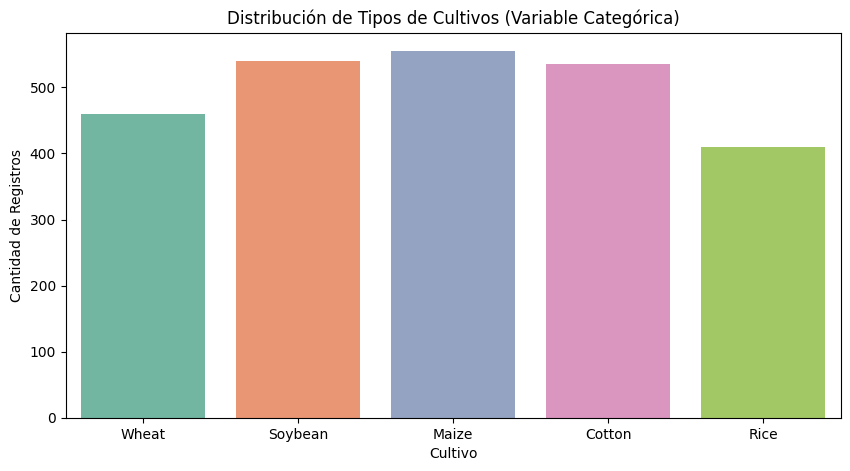

In [46]:
# 6. Búsqueda de Patrones: Distribución de Cultivos
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='crop_type', palette='Set2')
plt.title('Distribución de Tipos de Cultivos (Variable Categórica)')
plt.xlabel('Cultivo')
plt.ylabel('Cantidad de Registros')
plt.show()

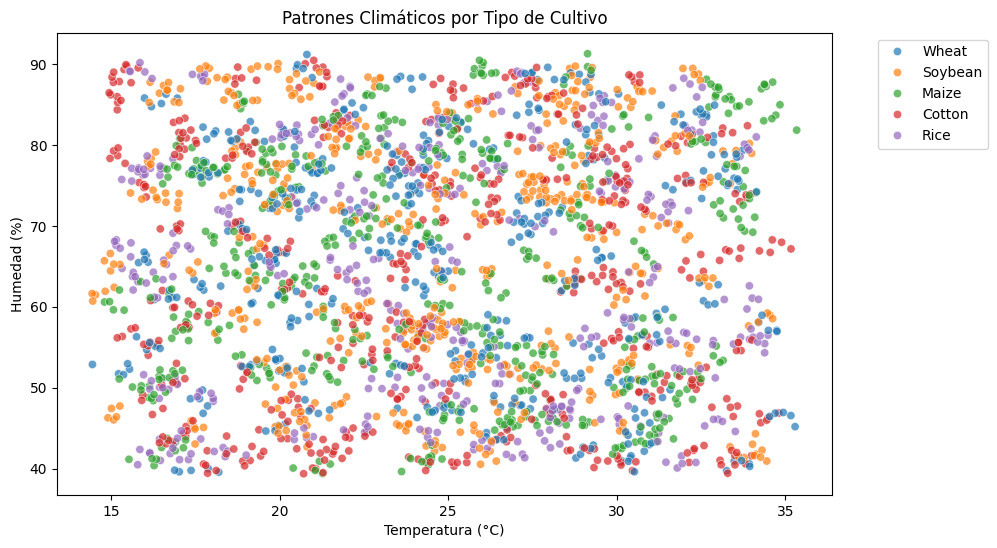

In [47]:
# 7. Búsqueda de Patrones: Relación Clima vs Nutrientes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature_C', y='humidity_%', hue='crop_type', alpha=0.7)
plt.title('Patrones Climáticos por Tipo de Cultivo')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Humedad (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

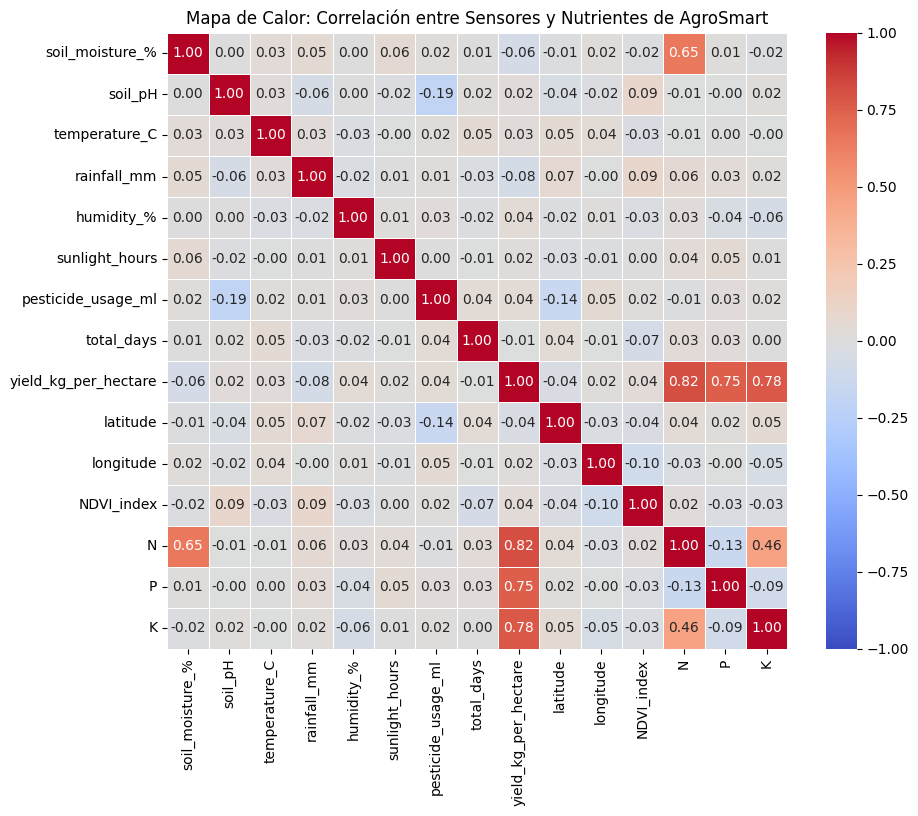

In [50]:
# 8. Matriz de Correlación (Heatmap)
# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Filtramos SOLO las columnas numéricas (la correlación requiere números, no texto)
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
matriz_corr = df[columnas_numericas].corr()

# Generamos el Mapa de Calor con Seaborn
sns.heatmap(matriz_corr,
            annot=True,          # Muestra los números dentro de los cuadros
            cmap='coolwarm',     # Colores: Rojo (correlación positiva), Azul (negativa)
            fmt=".2f",           # Redondea a 2 decimales
            linewidths=.5,       # Líneas de separación
            vmin=-1, vmax=1)     # Rango de la correlación (de -1 a 1)

plt.title('Mapa de Calor: Correlación entre Sensores y Nutrientes de AgroSmart')
plt.show()